# Exam 4th of January 2024, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [ ]:
# Insert your anonymous exam ID as a string in the variable below
examID="XXX"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


In this problem you will do rejection sampling from complicated distributions, you will also be using your samples to compute certain integrals, a method known as Monte Carlo integration: (Keep in mind that choosing a good sampling distribution is often key to avoid too much rejection)

1. [4p] Fill in the remaining part of the function `problem1_inversion` in order to produce samples from the below distribution using rejection sampling:

$$
    F[x] = 
    \begin{cases}
        0, & x \leq 0 \\
        \frac{e^{x^2}-1}{e-1}, & 0 < x < 1 \\
        1, & x \geq 1
    \end{cases}
$$

2. [2p] Produce 100000 samples (**use fewer if it times-out and you cannot find a solution**) and put the answer in `problem1_samples` from the above distribution and plot the histogram together with the true density. *(There is a timeout decorator on this function and if it takes more than 10 seconds to generate 100000 samples it will timeout and it will count as if you failed to generate.)*
3. [2p] Use the above 100000 samples (`problem1_samples`) to approximately compute the integral

$$
    \int_0^{1} \sin(x) \frac{2e^{x^2} x}{e-1} dx
$$
and store the result in `problem1_integral`.

4. [2p] Use Hoeffdings inequality to produce a 95\% confidence interval of the integral above and store the result as a tuple in the variable `problem1_interval`

5. [4p] Fill in the remaining part of the function `problem1_inversion_2` in order to produce samples from the below distribution using rejection sampling:
$$
    F[x] = 
    \begin{cases}
        0, & x \leq 0 \\
        20xe^{20-1/x}, & 0 < x < \frac{1}{20} \\
        1, & x \geq \frac{1}{20}
    \end{cases}
$$
Hint: this is tricky because if you choose the wrong sampling distribution you reject at least 9 times out of 10. You will get points based on how long your code takes to create a certain number of samples, if you choose the correct sampling distribution you can easily create 100000 samples within 2 seconds.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import pandas as pd

In [5]:

# Part 1
def problem1_inversion(n_samples=1):
    # Distribution from part 1
    # write the code in this function to produce samples from the distribution in the assignment
    # Make sure you choose a good sampling distribution to avoid unnecessary rejections
    
    f = lambda x: (2*x*np.e**x**2)/(np.e-1)

    result = []
    while (len(result) < n_samples):
        x1 = np.random.uniform(0,1)
        f_x = f(x1)
        M = f(1)
        x2 = np.random.uniform(0,1)
        if (x2 <= f_x/M):
            result.append(x1)
        else:
            continue
    return np.array(result)


In [ ]:
def problem1_inversion(n_samples=1):
    # my implementation
    f = lambda x: (2*x*np.e**x**2)/(np.e-1)

    result = []
    while (len(result) < n_samples):
        x = np.random.uniform(0,1)
        M = f(1)
        y = np.random.uniform(0, M)
        f_x = f(x)
        if (y <= f_x):
            result.append(x)
        else:
            continue
    return np.array(result)

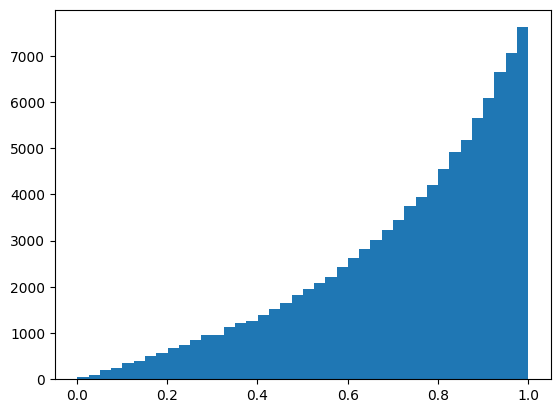

In [11]:
# Part 2

problem1_samples = problem1_inversion(100000)

plt.hist(problem1_samples, bins=40)
plt.show()


In [12]:
# Part 3

problem1_integral = np.mean(np.sin(problem1_samples))
print(problem1_integral)


0.6524164774654481


In [14]:
# Part 4
f = lambda x: np.sin(x)*(2*x*np.e**x**2)/(np.e-1)
X_n = problem1_integral
mu = integrate.quad(f, 0, 1)
epsilon = 1/np.sqrt(2*100000)*np.sqrt(np.log(2/0.05))



problem1_interval = [X_n - epsilon, X_n + epsilon]

print(epsilon)
print(problem1_interval)


0.004294694083467376
[np.float64(0.6481217833819807), np.float64(0.6567111715489155)]


In [ ]:
# Part 5

def problem1_inversion_2(n_samples=1):
    
    f = lambda x: (20*(x+1)*np.e**(20-1/x))/(x)

    result = []
    while (len(result) < n_samples):
        x1 = np.random.uniform(0,1)
        f_x = f(x1)
        M = f(1)
        x2 = np.random.uniform(0,1)
        if (x2 <= f_x/M):
            result.append(x1)
        else:
            continue
    return np.array(result)
    return XXX

---
#### Local Test for Exam vB, PROBLEM 1
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.

In [ ]:

# This cell is just to check that you got the correct formats of your answer
import numpy as np
try:
    assert(isinstance(problem1_inversion(10), np.ndarray)) 
except:
    print("Try again. You should return a numpy array from problem1_inversion")
else:
    print("Good, your problem1_inversion returns a numpy array")

try:
    assert(isinstance(problem1_samples, np.ndarray)) 
except:
    print("Try again. your problem1_samples is not a numpy array")
else:
    print("Good, your problem1_samples is a numpy array")

try:
    assert(isinstance(problem1_integral, float)) 
except:
    print("Try again. your problem1_integral is not a float")
else:
    print("Good, your problem1_integral is a float")

try:
    assert(isinstance(problem1_interval, list) or isinstance(problem1_interval, tuple)) , "problem1_interval not a tuple or list"
    assert(len(problem1_interval) == 2) , "problem1_interval does not have length 2, it should have a lower bound and an upper bound"
except Exception as e:
    print(e)
else:
    print("Good, your problem1_interval is a tuple or list of length 2")

try:
    assert(isinstance(problem1_inversion_2(10), np.ndarray)) 
except:
    print("Try again. You should return a numpy array from problem1_inversion_2")
else:
    print("Good, your problem1_inversion_2 returns a numpy array")

---
## Exam vB, PROBLEM 2
Maximum Points = 13


Let us build a proportional model ($\mathbb{P}(Y=1 \mid X) = G(\beta_0+\beta \cdot X)$ where $G$ is the logistic function) for the spam vs not spam data. Here we assume that the features are presence vs not presence of a word, let $X_1,X_2,X_3$ denote the presence (1) or absence (0) of the words $("free", "prize", "win")$.

1. [2p] Load the file `data/spam.csv` and create two numpy arrays, `problem2_X` which has shape (n_emails,3) where each feature in `problem2_X` corresponds to $X_1,X_2,X_3$ from above, `problem2_Y` which has shape **(n_emails,)** and consists of a $1$ if the email is spam and $0$ if it is not. Split this data into a train-calibration-test sets where we have the split $40\%$, $20\%$, $40\%$, put this data in the designated variables in the code cell.

2. [4p] Follow the calculation from the lecture notes where we derive the logistic regression and implement the final loss function inside the class `ProportionalSpam`. You can use the `Test` cell to check that it gives the correct value for a test-point.

3. [4p] Train the model `problem2_ps` on the training data. The goal is to calibrate the probabilities output from the model. Start by creating a new variable `problem2_X_pred` (shape `(n_samples,1)`) which consists of the predictions of `problem2_ps` on the calibration dataset. Then train a calibration model using `sklearn.tree.DecisionTreeRegressor`, store this trained model in `problem2_calibrator`.

4. [3p] Use the trained model `problem2_ps` and the calibrator `problem2_calibrator` to make final predictions on the testing data, store the prediction in `problem2_final_predictions`. Compute the $0-1$ test-loss and store it in `problem2_01_loss` and provide a $99\%$ confidence interval of it, store this in the variable `problem2_interval`, this should again be a tuple as in **problem1**.

In [30]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/spam.csv", encoding="latin-1")
problem2_X = pd.DataFrame()

problem2_X["X1"] = df["v2"].apply(lambda x: 1 if "free" in x else 0)
problem2_X["X2"] = df["v2"].apply(lambda x: 1 if "prize" in x else 0)
problem2_X["X3"] = df["v2"].apply(lambda x: 1 if "win" in x else 0)
problem2_X = problem2_X.to_numpy()
problem2_Y = df["v1"].replace({"spam":1, "ham":0}).to_numpy()
print(problem2_X.shape)
print(problem2_Y.shape)

X_train, X_test_calib, Y_train, Y_test_calib = train_test_split(problem2_X, problem2_Y, train_size=0.4, shuffle=True, stratify=problem2_Y)

print(Y_test_calib.shape)

X_test, X_calib, Y_test, Y_calib = train_test_split(X_test_calib, Y_test_calib, train_size=2/3)

print("Shapes:")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_calib: {X_calib.shape}, Y_calib: {Y_calib.shape}")
print(f"X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")

# Verify proportions
total = len(problem2_Y)

print("\nProportions:")
print(f"Train: {len(Y_train) / total:.2%}")
print(f"Calib: {len(Y_calib) / total:.2%}")
print(f"Test:  {len(Y_test) / total:.2%}")

(5572, 3)
(5572,)
(3344,)
Shapes:
X_train: (2228, 3), Y_train: (2228,)
X_calib: (1115, 3), Y_calib: (1115,)
X_test:  (2229, 3),  Y_test:  (2229,)

Proportions:
Train: 39.99%
Calib: 20.01%
Test:  40.00%


/tmp/ipykernel_25998/132576015.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  problem2_Y = df["v1"].replace({"spam":1, "ham":0}).to_numpy()


In [72]:
# Part 2

class ProportionalSpam(object):
    def __init__(self):
        self.coeffs = None
        self.result = None
    
    # define the objective/cost/loss function we want to minimise
    def loss(self, X, Y, coeffs):
        Z = np.where(Y == 1, -1, 1)
        regression = coeffs[0] + np.dot(X, coeffs[1:])
        total_loss = np.sum(np.log(1 + np.exp(-Z * regression)))
        return total_loss


    def fit(self,X,Y):
        import numpy as np
        from scipy import optimize

        #Use the f above together with an optimization method from scipy
        #to find the coefficients of the model
        opt_loss = lambda coeffs: self.loss(X,Y,coeffs)
        initial_arguments = np.zeros(shape=X.shape[1]+1)
        self.result = optimize.minimize(opt_loss, initial_arguments,method='cg')
        self.coeffs = self.result.x
    
    def predict(self,X):
        #Use the trained model to predict Y
        if (self.coeffs is not None):
            G = lambda x: np.exp(x)/(1+np.exp(x))
            return np.round(10*G(np.dot(X,self.coeffs[1:])+self.coeffs[0]))/10 # This rounding is to help you with the calibration


In [73]:
prop_spam = ProportionalSpam()
print(prop_spam.loss(X_test, Y_test, coeffs=np.array([1,1,1,1])))

1055.4019208940315


In [ ]:
# Part 3
from sklearn.tree import DecisionTreeRegressor

problem2_ps = ProportionalSpam()
problem2_ps.fit(X_train, Y_train)

problem2_X_pred = problem2_ps.predict(X_calib)

problem2_calibrator = DecisionTreeRegressor()
problem2_calibrator.fit(problem2_X_pred.reshape(-1,1), Y_calib)


976.1000000000001


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [83]:
# Part 4

# These are the predicted probabilities
pred_raw = problem2_ps.predict(X_test)
pred_calib = problem2_calibrator.predict(pred_raw.reshape(-1,1))
pred_calib = (pred_calib >= 0.5).astype(int)
pred_raw = (pred_raw >= 0.5).astype(int)

problem2_final_predictions = np.column_stack([pred_raw, pred_calib])

# In order to compute this loss we first need to convert the predicted probabilities to a decision
# recall the Bayes classifier?
losses = (pred_calib!=Y_test)
problem2_01_loss = np.mean(losses)
print(problem2_01_loss)

# Recall the interval is given as a tuple (a,b) or a list [a,b]
epsilon = np.sqrt(np.var(losses)/(len(losses)*0.01))

problem2_interval = (problem2_01_loss - epsilon, problem2_01_loss + epsilon)
print(problem2_interval)

0.12830865859129656
(np.float64(0.057472612126444445), np.float64(0.19914470505614867))


---
#### Local Test for Exam vB, PROBLEM 2
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.

In [ ]:
try:
    import numpy as np
    test_instance = ProportionalSpam()
    test_loss = test_instance.loss(np.array([[1,0,1],[0,1,1]]),np.array([1,0]),np.array([1.2,0.4,0.3,0.9]))
    assert (np.abs(test_loss-1.2828629432232497) < 1e-6)
    print("Your loss was correct for a test point")
except:
    print("Your loss was not correct on a test point")

---
## Exam vB, PROBLEM 3
Maximum Points = 13


Consider the following four Markov chains, answer each question for all chains:

<img width="400px" src="pictures/MarkovA.png">Markov chain A</img>
<img width="400px" src="pictures/MarkovB.png">Markov chain B</img>
<img width="400px" src="pictures/MarkovC.png">Markov chain C</img>
<img width="400px" src="pictures/MarkovD.png">Markov chain D</img>

1. [2p] What is the transition matrix?
2. [2p] Is the Markov chain irreducible?
3. [3p] Is the Markov chain aperiodic? What is the period for each state?
4. [3p] Does the Markov chain have a stationary distribution, and if so, what is it?
5. [3p] Is the Markov chain reversible?

In [ ]:
# PART 1

#------------------------TRANSITION MATRIX -------------------------------
# Answer each one by supplying the transition matrix as a numpy array
# of shape (n_states,n_states), where state (A,B,...) corresponds to index (0,1,...)

problem3_A = np.array([[0.8, 0.2, 0.0, 0.0],
                    [0.6, 0.2, 0.2, 0.0],
                    [0.0, 0.4, 0.0, 0.6],
                    [0.0, 0.0, 0.8, 0.2]])

problem3_B    = np.array([[0.0, 0.2, 0.0, 0.8],
                        [0.0, 0.0, 1.0, 0.0],
                        [0.0, 1.0, 0.0, 0.0],
                        [0.5, 0.0, 0.5, 0.0]])

problem3_C    = np.array([[0.2, 0.3, 0.0, 0.0, 0.5],
                        [0.2, 0.2, 0.6, 0.0, 0.0],
                        [0.0, 0.4, 0.0, 0.6, 0.0],
                        [0.0, 0.0, 0.0, 0.6, 0.4],
                        [0.0, 0.0, 0.0, 0.4, 0.6]])

problem3_D    = np.array([[0.8, 0.2, 0.0, 0.0],
                        [0.6, 0.2, 0.2, 0.0],
                        [0.0, 0.4, 0.0, 0.6],
                        [0.1, 0.0, 0.7, 0.2]])

In [ ]:
# PART 2
#------------------------REDUCIBLE -------------------------------
# Answer each one with a True or False

problem3_A_irreducible = True
problem3_B_irreducible = False
problem3_C_irreducible = False
problem3_D_irreducible = True


In [ ]:
# PART 3
#------------------------APERIODIC-------------------------------
# Answer each one with a True or False

problem3_A_is_aperiodic = True
problem3_B_is_aperiodic = False
problem3_C_is_aperiodic = True
problem3_D_is_aperiodic = True

# Answer the following with the period of the states as a numpy array
# of shape (n_states,)

problem3_A_periods = [1,1,1,1]
problem3_B_periods = [2,2,2,2]
problem3_C_periods = [1,1,1,1]
problem3_D_periods = [1,1,1,1]


In [10]:
# PART 4
#------------------------STATIONARY DISTRIBUTION-----------------
# Answer each one with a True or False

problem3_A_has_stationary = True
problem3_B_has_stationary = False
problem3_C_has_stationary = False
problem3_D_has_stationary = True

# Answer the following with the stationary distribution as a numpy array of shape (n_states,)
# if the Markov chain has a stationary distribution otherwise answer with False

def stationary_dist(P):
    eigenvals, eigenvecs = np.linalg.eig(P.T)

    # find the index of the eigenvalue that is 1
    index = np.argmin(np.abs(eigenvals - 1))

    stat = eigenvecs[:, index].flatten() # getting eigenvec with eigenval 1
    stat = stat / np.sum(stat) #normalizing vector
    return stat


problem3_A_stationary_dist = stationary_dist(problem3_A)
problem3_B_stationary_dist = False
problem3_C_stationary_dist = False
problem3_D_stationary_dist = stationary_dist(problem3_D)

print(problem3_A_stationary_dist)
print(problem3_D_stationary_dist)

[0.61538462 0.20512821 0.1025641  0.07692308]
[0.64516129 0.20430108 0.08602151 0.06451613]


In [ ]:
def find_reversible_distribution(P, tol=1e-8):
    n = P.shape[0]
    
    # Krok 1: Znajdź lewy wektor własny dla λ=1
    eigenvals, eigenvecs = np.linalg.eig(P.T)

    # find the index of the eigenvalue that is 1
    index = np.argmin(np.abs(eigenvals - 1))

    pi = eigenvecs[:, index].flatten() # getting eigenvec with eigenval 1
    pi = pi / np.sum(pi) #normalizing vector
    

    pi[np.abs(pi) < tol] = 0
    if np.any(pi < 0):
        return False # To by oznaczało brak fizycznego rozkładu
    
    # Verifying reversibility
    for i in range(n):
        for j in range(i + 1, n): 
            if not np.isclose(pi[i]*P[i,j], pi[j]*P[j,i], atol=tol):
                return False
                
    return True


In [15]:
# PART 5
#------------------------REVERSIBLE-----------------
# Answer each one with a True or False

problem3_A_is_reversible = find_reversible_distribution(problem3_A)
problem3_B_is_reversible = False
problem3_C_is_reversible = False
problem3_D_is_reversible = find_reversible_distribution(problem3_D)

print(problem3_A_is_reversible)
print(problem3_B_is_reversible)
print(problem3_C_is_reversible)
print(problem3_D_is_reversible)

True
False
False
False
